In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

# The DataFrame

The dataset contains 4,100 client records from a Portuguese bank (2008–2013), with 19 features including demographics, financial data, marketing activity, and economic indicators, plus a binary target (y) indicating deposit subscription.

The main goal of this analysis is to predict whether a client subscribes.

The Exploratory Data Analysis (EDA) will helps identify patterns, understand distributions, and find relationships with the target while ML Supervised models such as Logistic Regression and Decision tree will help in predicting whether clients, based on features, will subscribe or not.

In [2]:
# Import file on Google Colab space
from google.colab import files
uploaded = files.upload()

Saving MMA marketing_data_sample.csv to MMA marketing_data_sample.csv


### File format checking

In [3]:
# Check What data type is our file
type(uploaded)

dict

Since the dataset is stored in a dictionary format, it must first be converted into a fromat suitable for analysis.

In the specific, it will be transformed into a format that can be loaded into a pandas DataFrame, helpin  data manipulation, exploration, and visualization.

In [4]:
import io

# Get the first uploaded file from the uploaded files dictionary
file_name = list(uploaded.values())[0]

# Convert the uploaded file from bytes format to a UTF-8 decoded string
df = file_name.decode('utf-8')

# Read the decoded string as a CSV file and load it into a pandas DataFrame
df = pd.read_csv(io.StringIO(df))

In [5]:
pd.set_option('display.max_columns', None) # Helps to visualise all the columns
df.head()

,age,job,marital,k,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


# EDA - Exploratory Data Analysis

## Inspect Data

Inspection of the dataset serve to understand its shape, identify any missing values, and review data types.

This step also helps identify whether any cleaning or preprocessing is needed to prepare the data for analysis.

In [6]:
# Inspect Shape
print("DataFrame Shape \n")
print(f'The DataFrame has {df.shape[0]} rows and {df.shape[1]} columns')

DataFrame Shape 

The DataFrame has 4100 rows and 21 columns


In [7]:
# Inspect Dtypes
print('Dtypes Exploration \n')
for i in df.columns:
  dftypes = df[i].dtype
  print(f'The column {i} is a {dftypes}')

Dtypes Exploration 

The column age is a int64
The column job is a object
The column marital is a object
The column k is a object
The column default is a object
The column housing is a object
The column loan is a object
The column contact is a object
The column month is a object
The column day_of_week is a object
The column duration is a int64
The column campaign is a int64
The column pdays is a int64
The column previous is a int64
The column poutcome is a object
The column emp.var.rate is a float64
The column cons.price.idx is a float64
The column cons.conf.idx is a float64
The column euribor3m is a float64
The column nr.employed is a float64
The column y is a object


In [8]:
#Inspect Null Values
print('Null Values Exploration \n')
for i in df.columns:
  nullval = df[i].isnull().sum()/len(df) * 100
  print(f'The column {i} has {nullval} % of null values')
print('\n')

Null Values Exploration 

The column age has 0.0 % of null values
The column job has 0.0 % of null values
The column marital has 0.0 % of null values
The column k has 0.0 % of null values
The column default has 0.0 % of null values
The column housing has 0.0 % of null values
The column loan has 0.0 % of null values
The column contact has 0.0 % of null values
The column month has 0.0 % of null values
The column day_of_week has 0.0 % of null values
The column duration has 0.0 % of null values
The column campaign has 0.0 % of null values
The column pdays has 0.0 % of null values
The column previous has 0.0 % of null values
The column poutcome has 0.0 % of null values
The column emp.var.rate has 0.0 % of null values
The column cons.price.idx has 0.0 % of null values
The column cons.conf.idx has 0.0 % of null values
The column euribor3m has 0.0 % of null values
The column nr.employed has 0.0 % of null values
The column y has 0.0 % of null values




Some variables may contain “Unknown” instead of standard missing values (NaN).

It is important to identify these to decide whether they should be treated as missing values during preprocessing.

In [9]:
# Inspect presence of Unknown val

for col in df.columns:
  unknown_val = df[col].isin(['Unknown','unknown']).sum()/len(df) * 100
  print(f'the column {col} has {unknown_val} % of values unknown')

the column age has 0.0 % of values unknown
the column job has 0.9512195121951219 % of values unknown
the column marital has 0.2682926829268293 % of values unknown
the column k has 4.073170731707317 % of values unknown
the column default has 19.48780487804878 % of values unknown
the column housing has 2.5365853658536586 % of values unknown
the column loan has 2.5365853658536586 % of values unknown
the column contact has 0.0 % of values unknown
the column month has 0.0 % of values unknown
the column day_of_week has 0.0 % of values unknown
the column duration has 0.0 % of values unknown
the column campaign has 0.0 % of values unknown
the column pdays has 0.0 % of values unknown
the column previous has 0.0 % of values unknown
the column poutcome has 0.0 % of values unknown
the column emp.var.rate has 0.0 % of values unknown
the column cons.price.idx has 0.0 % of values unknown
the column cons.conf.idx has 0.0 % of values unknown
the column euribor3m has 0.0 % of values unknown
the column n

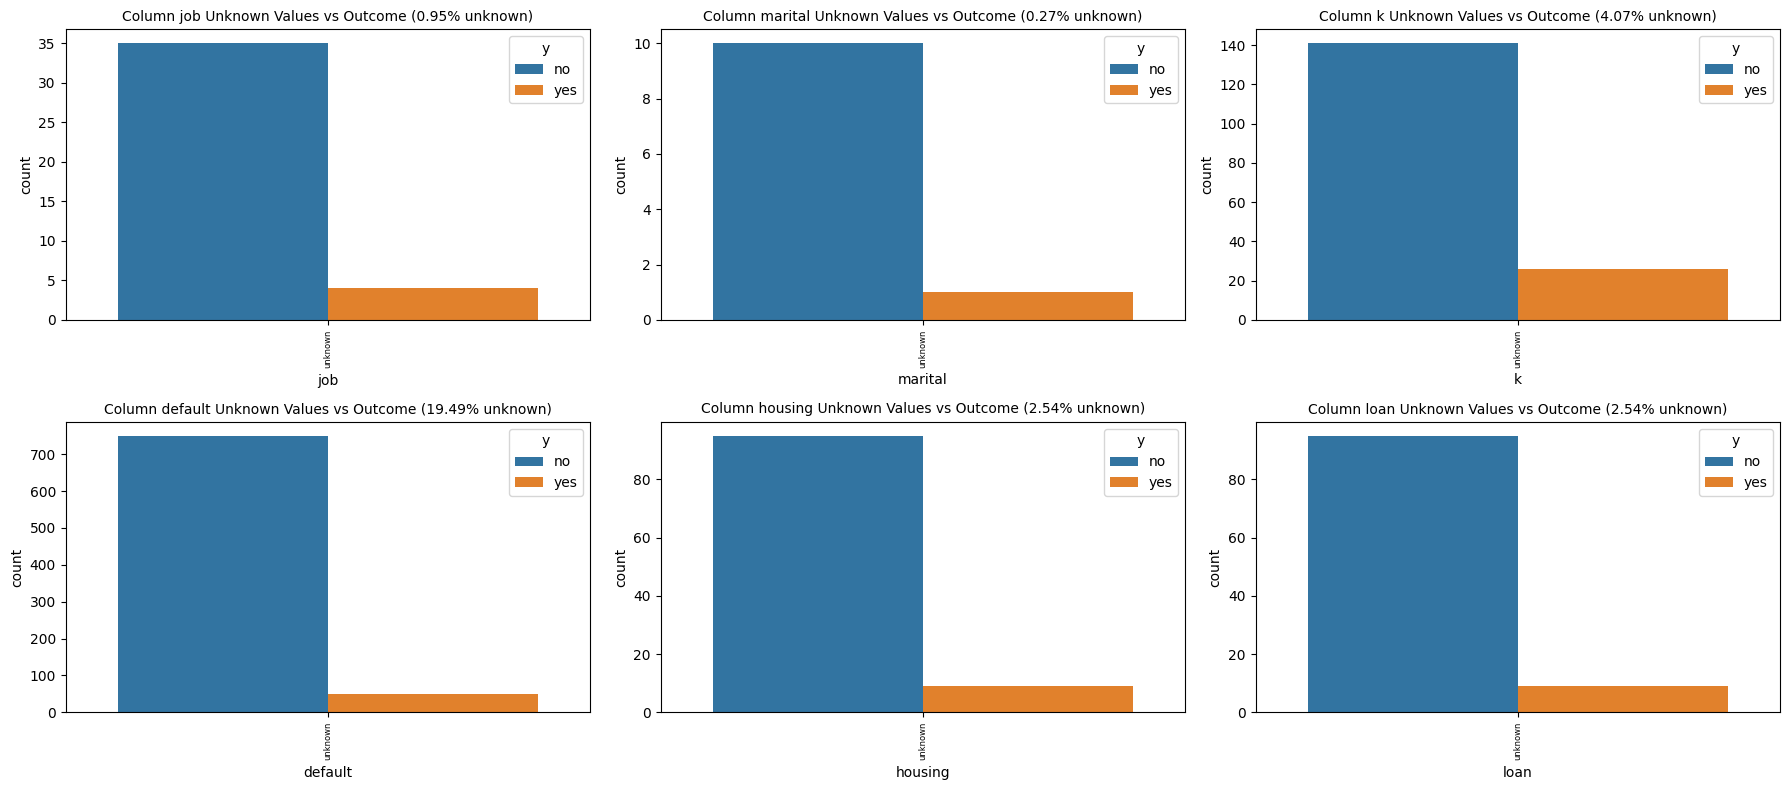

In [10]:
# Select specific categorical columns from the dataframe
columns = df[['job','marital','k','default','housing','loan']]

# Get a list of column names to iterate over
cols = columns.columns.tolist()

# Define how many columns per row will appear in the subplot grid
n_cols = 3

# Calculate the number of rows needed to fit all columns in the grid
# Ceiling division ensures enough rows even if len(cols) is not divisible by n_cols
n_rows = (len(cols) + n_cols - 1) // n_cols

# Create a figure and axes (subplots) for all plots
# figsize sets the total width and height of the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))

# Flatten the 2D array of axes into a 1D array for easier iteration
axes = axes.flatten()

# Loop over each column to create a countplot for unknown values
for i, col in enumerate(cols):

    # Filter the dataframe to only include rows where the current column is 'Unknown' or 'unknown'
    d = df[df[col].isin(['Unknown','unknown'])]
    # Compute percentage of unknowns
    unknown_val = df[col].isin(['Unknown','unknown']).sum() / len(df) * 100
    # Create a countplot for the filtered data, separated by the target variable 'y'
    sns.countplot(x=d[col], hue=d['y'], ax=axes[i])

    # Rotate x-axis labels 90 degrees and set font size to improve readability
    axes[i].tick_params(axis='x', rotation=90, labelsize=6)

    # Include it in the title
    axes[i].set_title(f'Column {col} Unknown Values vs Outcome ({unknown_val:.2f}% unknown)', fontsize=10)

# Remove any unused subplots if the total number of columns isn't a multiple of n_cols
# This prevents empty axes from appearing in the figure
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Automatically adjust spacing between subplots to prevent overlapping labels and titles
plt.tight_layout()

# Finding

Different categorical features in the dataset include “unknown” values.
However, they represent only a small proportion of the observations.

These are mostly associated with y = no, suggesting a tendency toward negative responses when information is missing or unspecified.

Based on this, “unknown” values can be handled in different ways: retained as a separate category, imputed using appropriate methods, or potentially treated as negative if aligned with the analysis objectives.

For the purpouse of the Analysis the Unknown ahve been kept as a separate class.

# Data Distribution

               age     duration     campaign        pdays     previous  \
count  4100.000000  4100.000000  4100.000000  4100.000000  4100.000000   
mean     40.117073   256.754634     2.538537   960.243415     0.190732   
std      10.315182   254.399637     2.568833   192.349065     0.542609   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000   103.000000     1.000000   999.000000     0.000000   
50%      38.000000   181.000000     2.000000   999.000000     0.000000   
75%      47.000000   317.000000     3.000000   999.000000     0.000000   
max      88.000000  3643.000000    35.000000   999.000000     6.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx    euribor3m  nr.employed  
count   4100.000000     4100.000000    4100.000000  4100.000000  4100.000000  
mean       0.085171       93.580123     -40.498463     3.621421  5166.472780  
std        1.563183        0.579578       4.593385     1.733708    73.664618  
min       -3.4000

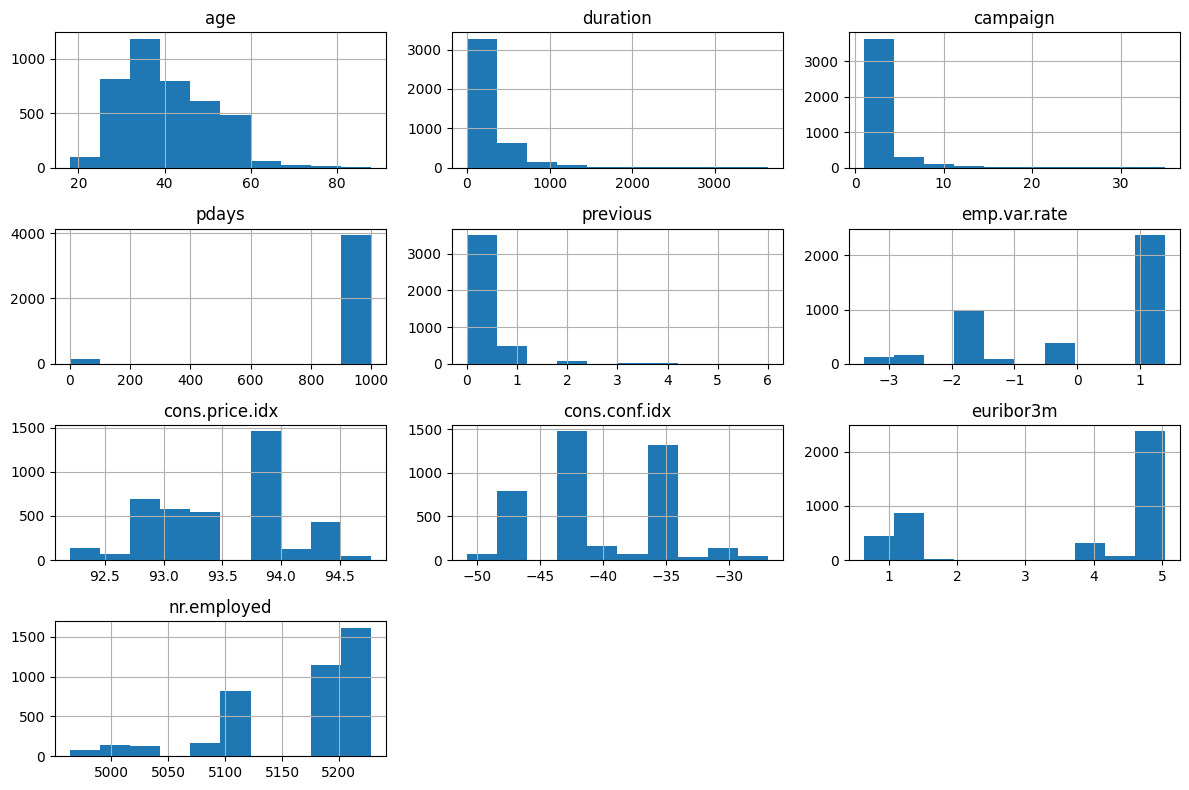

In [11]:
Numerical_Variables = df.select_dtypes(include=['int','float'])
Numerical_Variables.hist(figsize=(12,8))
plt.tight_layout();
print(Numerical_Variables.describe())

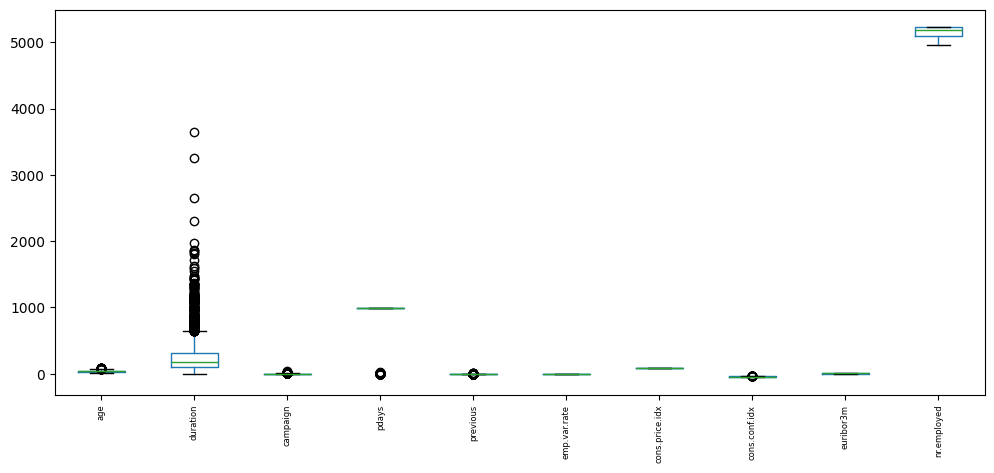

In [12]:
Numerical_Variables.boxplot(grid = False,figsize=(12,5))
plt.xticks(rotation = 90,fontsize =6)
plt.show()

# Findings

The average **age** of clients is around 40, with most between 32 and 47, indicating the main focsu is on middle-aged individuals.

**Call duration** is expressd in seconds and it varies widely with mean approx at 257 seconds and a amx duration of 3,600+, with longer calls likely linked to higher engagement.

The **campaign** variable shows most clients are contacted 1-2 times, wiyh some receiving more contacts.

For **historical contact**, most clients were not previously contacted (previous = 0), and pdays = 999 confirms limited engagement.

**Macroeconomic indicators** show variation: emp.var.rate ranges from -3.4 to 1.4, cons.price.idx is stable (93.6), cons.conf.idx is negative (-40.5), indicating low confidence, and euribor3m varies widely (0.635–5.045). nr.employed averages around 5,166.

Overall, the dataset has variables like call duration, contact history, and economic conditions likely playing a key role in predicting client responses.

# Outliers

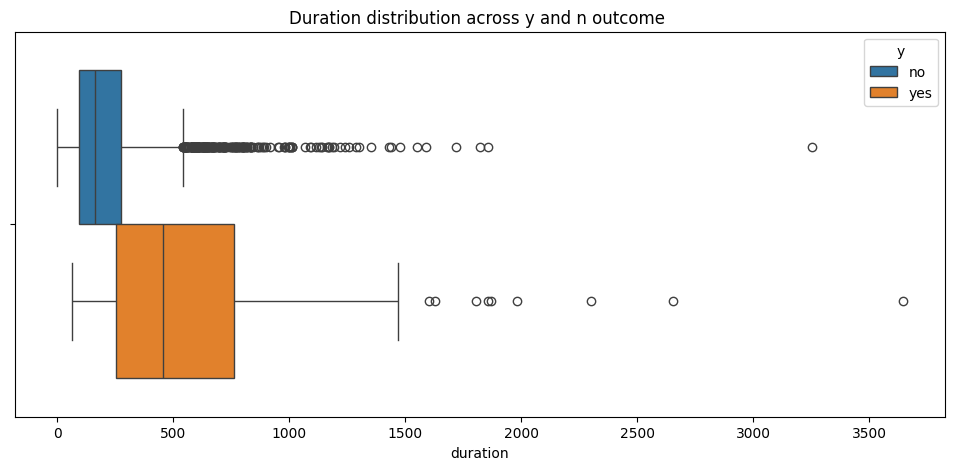

In [13]:
plt.figure(figsize=(12,5))
sns.boxplot(df,x='duration',hue = 'y')
plt.title('Duration distribution across y and n outcome ');

# Findings

The boxplots indicate that longer calls are more strongly associated with positive responses, suggesting call duration as a potential predictor.

The range of call durations varies widely, with a maximum exceeding 3,500 seconds. This corresponds to a call lasting approximately 50 minutes, which is a plausible value. Therefore, the final decision was made to retain this data point.

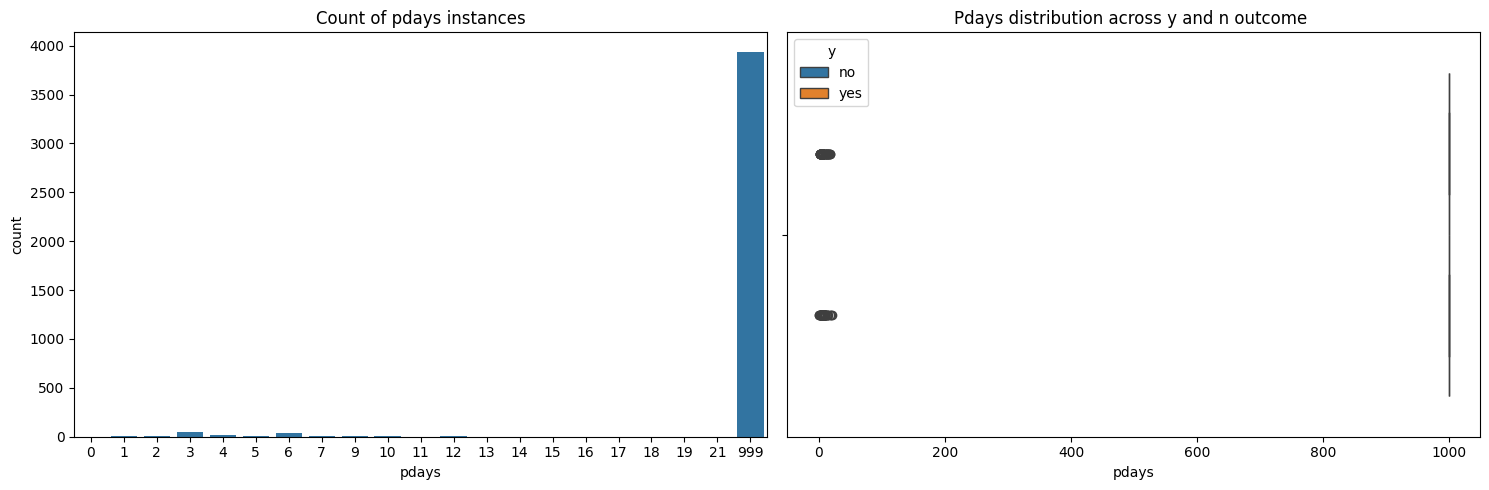

In [14]:
fig,axis=plt.subplots(1,2,figsize=(15,5))
sns.countplot(df,x='pdays',ax=axis[0])
axis[0].set_title('Count of pdays instances')
sns.boxplot(df,x='pdays',hue = 'y',ax=axis[1])
axis[1].set_title('Pdays distribution across y and n outcome ')
plt.tight_layout();

# Findings

For the Pdays feature, most clients have a value of 999, indicating they were not previously contacted.

This particular value could introduce bias in future data modeling. Therefore, the feature was transformed into a categorical variable by assigning categories based on “how much time has passed since the client was last contacted.”

In [15]:
df['pdays'].sort_values(ascending = True).unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  21, 999])

In [16]:
df1 = df.copy()

In [17]:
# Pdays goes from 0 to 21 days while 999 means clients has never been contacted
def pdays_cat(d):
  if d == 999:
    return 'Never'
  elif d <= 7 & d >= 0:
    return '1 Week'
  elif d <= 14:
    return '2 Weeks'
  elif d <= 21:
    return '3 Weeks'
  else:
    return 'More than 3 weeks ago'

df1['pdays_2'] = df1['pdays'].apply(pdays_cat)
df1.drop(columns='pdays',inplace=True)

This approach can improve the interpretation of this feature for a machine learning model, which might otherwise be misled by the extreme value of 999.

# Categorical Variables and Target

This offers  insight into how the target variable is distributed across categorical features, showing patterns linked to a higher likelihood of a positive outcome (“yes”).

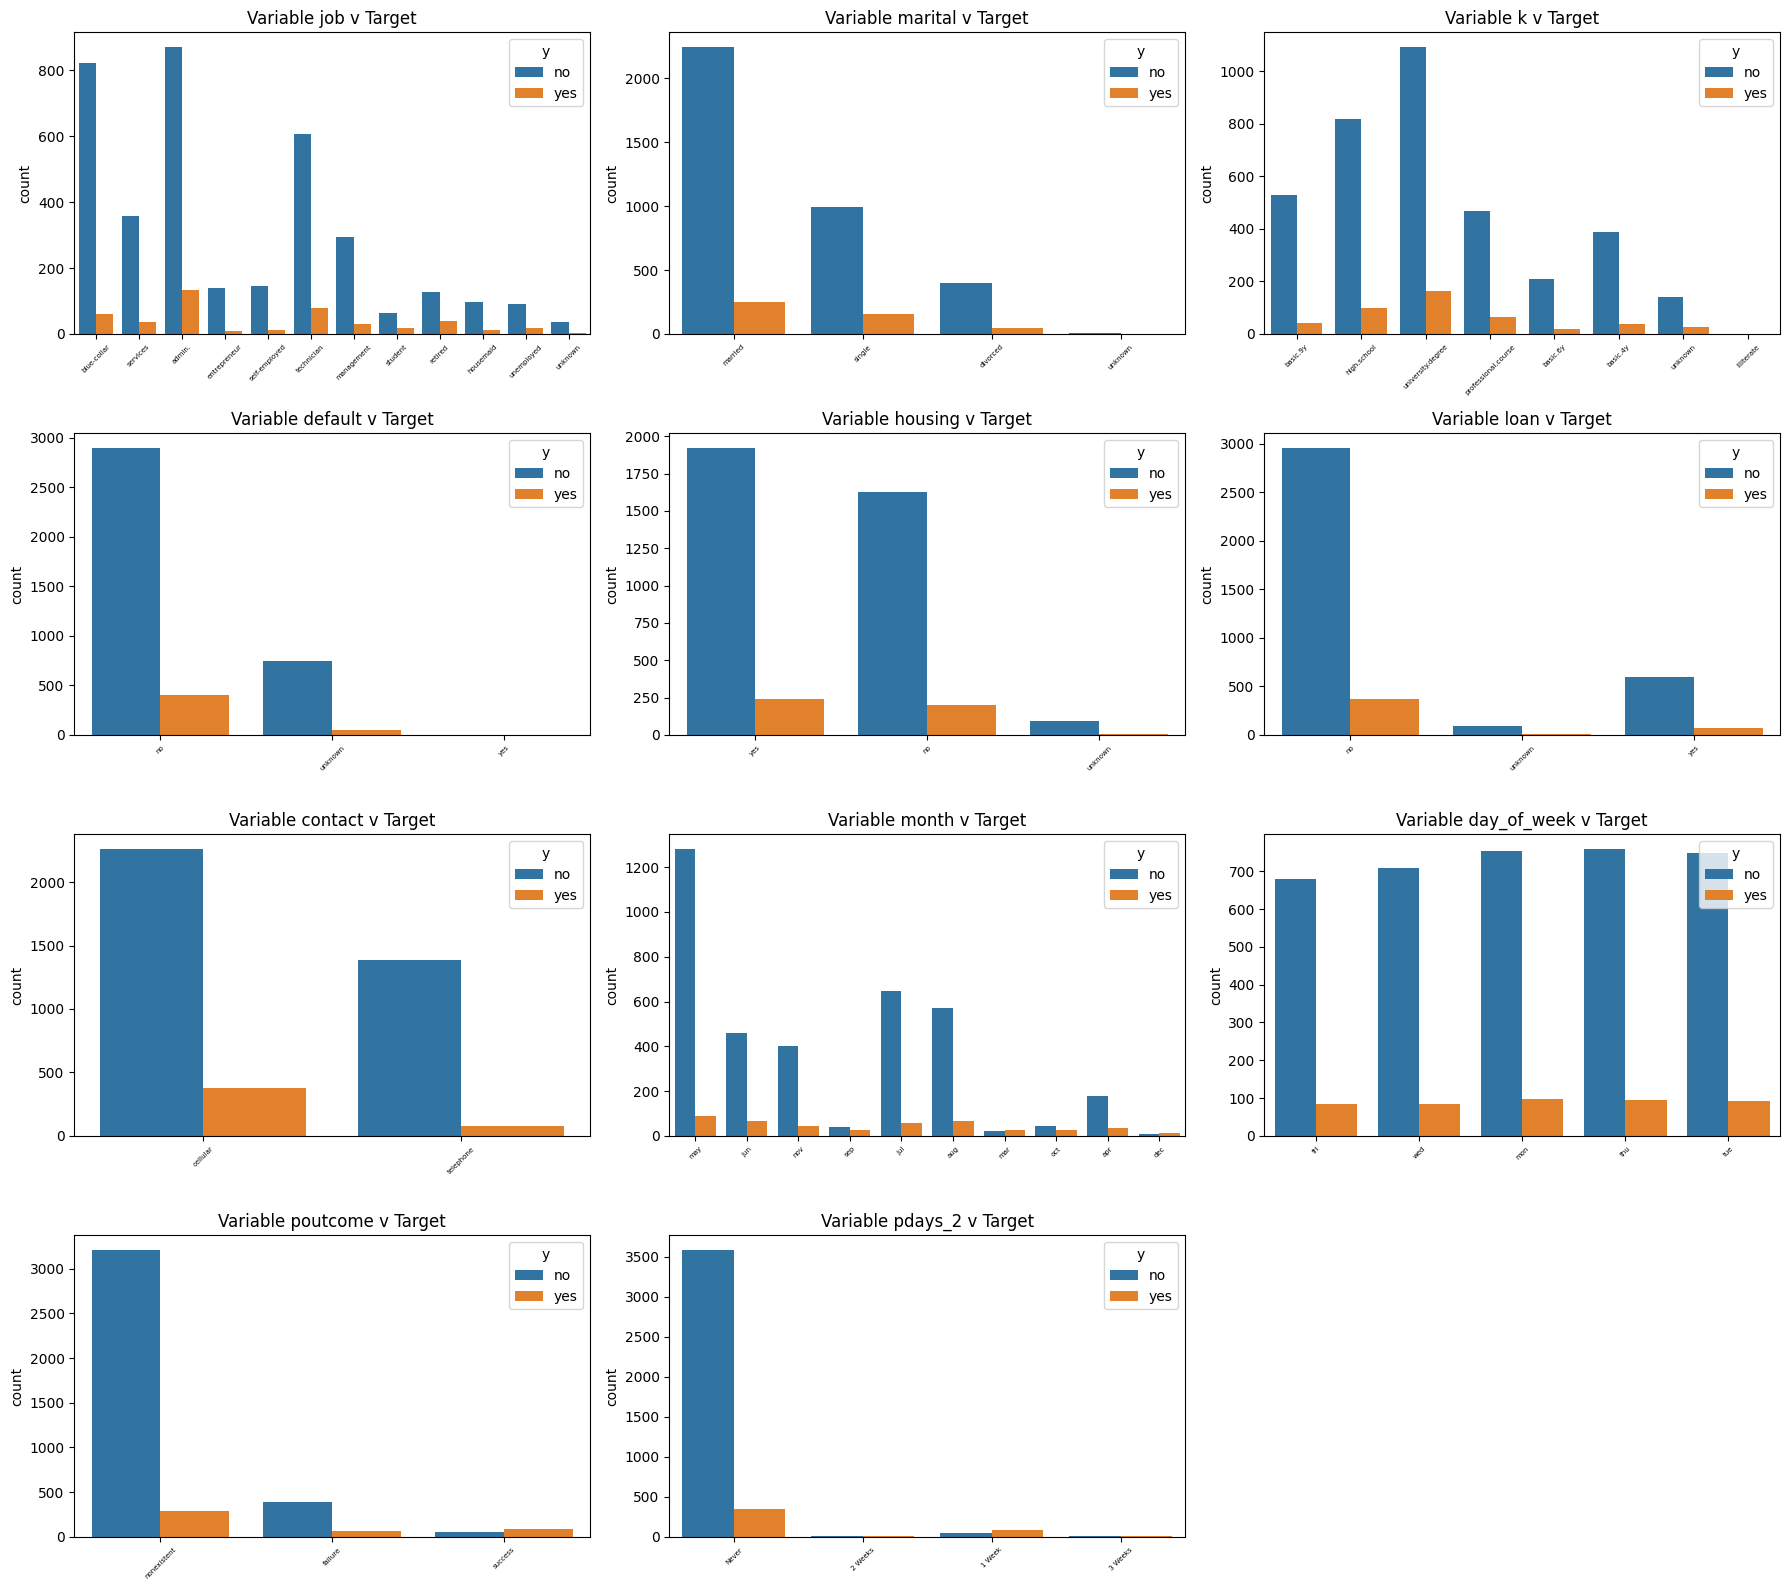

In [21]:
# Select all categorical columns (object type) from the dataframe
Categorical_Variables1 = df1.drop(columns='y').select_dtypes(include=['object'])

# Get the list of categorical column names to loop over
cols = Categorical_Variables1.columns.tolist()

# Define how many columns per row in the subplot grid
n_cols = 3

# Calculate the number of rows needed to fit all columns
# Uses ceiling division to ensure enough rows even if total columns isn't divisible by n_cols
n_rows = (len(cols) + n_cols - 1) // n_cols

# Create the figure and axes for the subplots
# figsize sets the total width and height of the entire figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))

# Flatten the 2D array of axes into a 1D array to make iteration easier
axes = axes.flatten()

# Loop over each categorical column to create a countplot and add a table
for i, col in enumerate(cols):

    # Create a countplot of the column, with bars separated by target variable 'y'
    sns.countplot(data=df1, x=col, hue='y', ax=axes[i])

    # Set the title of the subplot to indicate which variable is being plotted
    axes[i].set_title(f'Variable {col} v Target')

    # Remove the x-axis label since it is already indicated by the ticks
    axes[i].set_xlabel('')

    # Rotate the x-axis labels 45 degrees and set font size for readability
    axes[i].tick_params(axis='x', rotation=45, labelsize=5)


# Remove any unused subplots if the total number of categorical columns
# is not a perfect multiple of n_cols to avoid empty axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Automatically adjust spacing between subplots to prevent overlapping titles, labels, and tables
plt.tight_layout()

# Display all subplots with countplots and tables in a single figure
plt.show()

# Finding

Analysis of categorical features reveals different patterns linked to positive outcomes (“yes”).

Retired clients and students show higher “yes” rates, while blue-collar and service workers are mostly “no,” indicating job might influence the final outcome.

Singles are slightly more likely to respond positively, while married clients dominate the dataset but have a lower proportion of “yes.”

Higher education levels are associated with more positive responses, while basic education aligns with “no.”

The default variable provides almost no predictive value, as almost all observations are “no” or “unknown.”

Housing and loan status show small differences, with slightly more “yes” among clients without loans or housing credit.

Cellular contact methods has more positive responses than telephone, and there is a also seasonal effect as months of March, September, October, and December show higher “yes” rates.

The day of the week has low impact showing a uniform distribution.

Previous campaign outcomes show to have some impact as clients with prior success look to be more likely to respond positively.

Finally, most clients were never contacted before, with few “yes” responses.
However Pdays_2 shows how customers who have never been contacted have an  higher number of subscritpion, hovere the chart also shows how calling a clients after 1 week might increase the probability of final subscription.

Overall, job, education, contact method, month, and previous campaign outcome are the most informative features, while day of the week and loan status have limited predictive power.

These insights can guide feature selection and model interpretation.

# Correlation between Numerical Feature and Target

<Axes: >

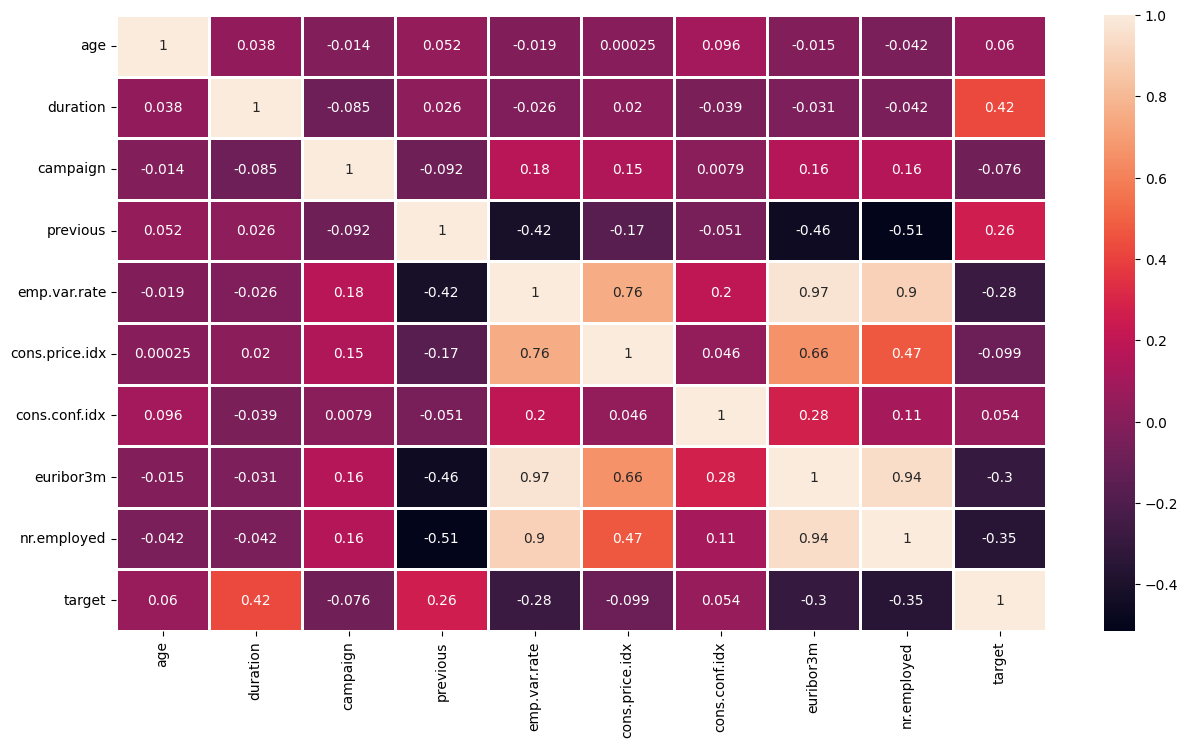

In [20]:
# transform the target variable in numeric
Numerical_Variables1 = df1.select_dtypes(include=['int','float'])
Numerical_Variables1['target'] = df1['y'].map({'no':0,'yes':1})
plt.figure(figsize=(15,8))
sns.heatmap(Numerical_Variables1.corr(),annot = True,linewidth = 2,linecolor = 'w')

# Findings

Correlation analysis with the target variable shows the levels of association across numerical features.

**Age** has a weak positive correlation (0.06), indicating minimal linear impact on subscription probability.

**Call duration** is the strongest predictor (0.42), with longer calls linked to higher success, highlighting its importance as an indicator of customer interest.

**Campaign shows** a weak negative correlation (-0.08), suggesting the number of contacts in the current campaign has little effect.

**Previous contacts** exhibit a moderate positive correlation (0.26), showing that clients contacted before are more likely to subscribe again.

Among **macroeconomic variables**, employment variation rate has a slight negative effect (-0.28), consumer price index is almost negligible (-0.10), and consumer confidence index has a minimal positive effect (0.05).

**Euribor3m** shows a moderate negative correlation (-0.30), suggesting higher interest rates decrease subscription likelihood, while number of employed individuals also has a moderate negative correlation (-0.35), possibly reflecting broader economic conditions.

Overall, call duration, previous contact, and recent engagement are the most influential predictors, while age and most macroeconomic indicators have limited linear impact.

# Target Variable Inspection



In [ ]:
print(df['y'].value_counts())
print('\n')
print(df['y'].value_counts(normalize = True))

y
no     3649
yes     451
Name: count, dtype: int64


y
no     0.89
yes    0.11
Name: proportion, dtype: float64


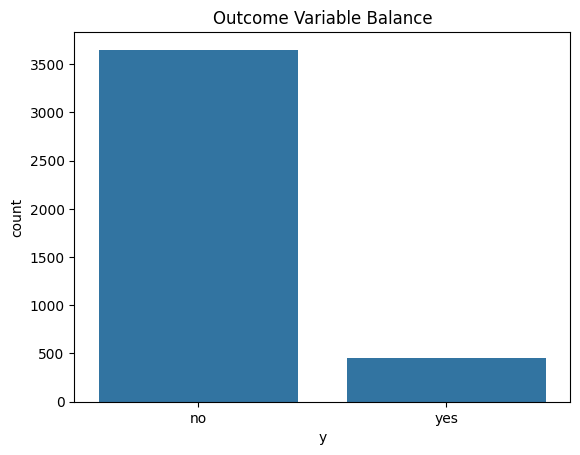

In [ ]:
sns.countplot(data = df,x = 'y')
plt.title('Outcome Variable Balance');

# Findings

The dataset is highly imbalanced for the target variable y: of 4,100 observations, 3,649 (89%) are “no” and only 451 (11%) are “yes.”

This shows that most customers did not subscribe, and predictive models will need to address this imbalance to avoid biased results.

# In Conclusion

The exploratory analysis shown some key insights from the dataset.

**The target is highly imbalanced** (89% “no,” 11% “yes”), requiring careful adjustment during modeling.

Some **categorical features** contain unknown values most under 5%, except default (19%) often associated with negative responses, suggesting they carry meaningful information.

Among **numerical variables**, duration shows the strongest positive correlation with subscription, while pdays, previous, euribor3m, and nr.employed have moderate predictive relevance.


# Predictive Analysis

We will develop and compare two classification models to identify clients likely to subscribe to the long-term deposit account through the Mass Market Campaign.

These supervised machine learning models aim to predict positive responses and evaluate which approach performs better.

## We split the dataset in train and test dataset before implement our model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df1['Target']=df1['y'].map({'no':0,'yes':1})
df1.drop(columns='y',inplace=True)


In [ ]:
df1=df1[['age', 'job', 'marital', 'k', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'pdays_2', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'Target']]

# Select Predictors and Dependat Variable
X = df1.drop(columns='Target')
y = df1['Target']

In [ ]:
# Split the dataset in train and test to avoid the problem of Data Leakage

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42,stratify = y) # stratify mantain proportion between classes



# Logistic Regression

# PREPROCESSING

# Variable Encoding

Categorical variables were first converted into numerical format using label encoding, which assigns an integer to each category to make them interpretable by the model.

We applied one-hot encoding, creating binary variables for each category of the categorical predictors, allowing the model to handle categorical data.

In [ ]:
#Create the encoder for the categorical variables
encoder = OneHotEncoder(handle_unknown='ignore',
    sparse_output=False,
    drop='first')
# extract object columns and numerical columns from dataset
categorical_=X_train.select_dtypes(include='object').columns
numerical_= X_train.select_dtypes(include = ['int','float']).columns

In [ ]:
#Define the new trainig set from the division
X_train_num = X_train[numerical_]
X_test_num = X_test[numerical_]

In [ ]:
#We fit the encoder on train set and transform the test.
X_train_cat = encoder.fit_transform(X_train[categorical_])
X_test_cat = encoder.transform(X_test[categorical_])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# once we have separated and encoded the categorical features then we will need them back into a unique dataset with the numerical.
# we will extract then the name of the new features after the encoding

cat_columns = encoder.get_feature_names_out(categorical_) # get back categorical name

In [ ]:
# We are now going to convert the new features in a Data Frame format so will be easy to connect again with the numerical features
#transform in dataframe the categorical variables after the encoding
X_train_cat = pd.DataFrame(X_train_cat, columns=cat_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_columns, index=X_test.index)

In [ ]:
# create a new final dataframe with the encoded variables and the numerical
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

The new shape of the 2 set is of 53 columns

In [ ]:
X_train.shape

(2747, 53)

# Scale the features of the Dataset

After splitting and encoding the dataset, the next step is to standardize the features, since they may be on different scales.

This ensures that all variables contribute equally to the model and improves the performance of algorithms sensitive to feature magnitude.

In [ ]:
scaler = StandardScaler() # As values are from different scale we use standard scaler to avoid any bias
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

# Balancing the Dataset

Since the dataset is heavily imbalanced toward the negative class, the next step is to apply SMOTE (Synthetic Minority Over-sampling Technique).

This method generates synthetic samples for the minority class to rebalance the dataset and prevent the model from being biased toward the majority class.

In [ ]:
# Import the relevant libraries to resample our train set
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [ ]:
X_train_res, y_train_res= smote.fit_resample(X_train_Scaled,y_train)

Target
0    2445
1    2445
Name: count, dtype: int64


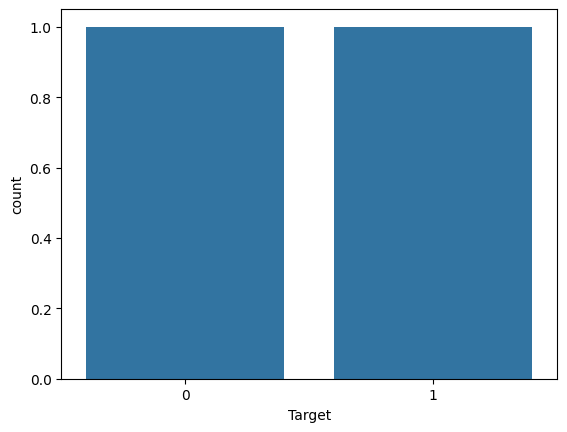

In [ ]:
sns.countplot(y_train_res.value_counts())
print((y_train_res).value_counts()) # the SMOTE resampling has rebalanced our target variable

We will use the Logit function from statsmodels to fit a logistic regression and examine the summary, which provides information on the significance of each feature.

Features with a p-value below 0.05 are typically considered statistically significant and relevant for predicting the target.

In [ ]:
import statsmodels.api as sm

In [ ]:
# Transform X_resampled and y_resampled in DataFrames
X_res = pd.DataFrame(X_train_res,columns=X_train.columns)
y_res = pd.DataFrame(y_train_res)

# Run a logit model from statsmodel to analyse the coefficients and their p_value and see how statistically significant are our predictors for the model

X2 = sm.add_constant(X_res)
model_log = sm.Logit(y_res,X2).fit()
print(model_log.summary())

Optimization terminated successfully.
         Current function value: 0.268418
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:                 4890
Model:                          Logit   Df Residuals:                     4837
Method:                           MLE   Df Model:                           52
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.6128
Time:                        13:14:16   Log-Likelihood:                -1312.6
converged:                       True   LL-Null:                       -3389.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.1933      0.093    -23.482      0.000      -2.376      -2.

# Findings

The logistic regression summary provides p-values for each predictor, indicating which variables are statistically significant at the 5% level.

Among the variables, age, duration, and previous contacts are positive and highly significant, increasing the likelihood of a positive response, while emp.var.rate has a strong negative effect. Macroeconomic indicators like cons.price.idx and cons.conf.idx show positive associations.

For categorical variables, certain job categories (blue-collar, management, self-employed) are significant with negative effects, while being unemployed is positive. Marital status also matters, with married and single clients more likely to respond positively.

Education, housing loans, and contact type have mixed effects, with some showing negative impacts. Time variables, especially months like March, September, and December, are influential, whereas day of the week has limited impact.

Several variables, including campaign, euribor3m, multiple job and education categories, and some month/day indicators, are not significant and could be removed to simplify the model. Multicollinearity issues appear in variables with undefined statistics.

Overall, call duration, prior contacts, macroeconomic conditions, and key demographics are the main drivers, while many other variables add little explanatory power and may complicate the model.

In [ ]:
# Define the list of columns to be dropped
columns_to_drop = [
    'campaign',
    'euribor3m',
    'job_services',
    'job_student',
    'job_technician',
    'marital_unknown',
    'k_basic.9y',
    'k_high.school',
    'k_professional.course',
    'k_university.degree',
    'default_unknown',
    'housing_unknown',
    'loan_unknown',
    'loan_yes',
    'month_aug',
    'month_jul',
    'month_jun',
    'month_nov',
    'month_oct',
    'day_of_week_mon',
    'day_of_week_thu',
    'day_of_week_wed',
    'pdays_2_Never'
]

# Create X_train_res1 by dropping columns from X_res
X_train_res1 = X_res.drop(columns=columns_to_drop)

# Convert X_test_Scaled (numpy array) into a DataFrame with the full set of original columns
X_test_df = pd.DataFrame(X_test_Scaled, columns=X_train.columns)

# Drop the same columns from the X_test DataFrame to match X_train_res1
X_test_final = X_test_df.drop(columns=columns_to_drop)

# Model Logistic Regression Initialisation

In [ ]:

model_lr = LogisticRegression(max_iter=5000)

In [ ]:
model_lr.fit(X_train_res1, y_train_res)

LogisticRegression(max_iter=5000)

In [ ]:
res_lr = model_lr.predict(X_test_final)

res_lr_df =pd.DataFrame(X_test_final)
res_lr_df['result'] = res_lr

res_lr_df

,age,duration,previous,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_unemployed,job_unknown,marital_married,marital_single,k_basic.6y,k_unknown,housing_yes,contact_telephone,month_dec,month_mar,month_may,month_sep,day_of_week_tue,pdays_2_2 Weeks,pdays_2_3 Weeks,poutcome_nonexistent,poutcome_success,result
0,1.151709,0.922227,1.422535,-2.231365,-1.591543,2.233449,-2.020433,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,0.932727,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,-2.397788,5.171796,1
1,0.086149,-0.103366,1.422535,-0.757990,1.054435,0.632208,-2.751785,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,4.850442,0.932727,-0.760151,-0.076542,-0.099632,-0.710778,7.748835,-0.511692,-0.068956,-0.054044,-2.397788,-0.193356,0
2,0.667363,-0.237807,-0.352887,-2.231365,-1.591543,2.233449,-2.020433,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,-1.232020,1.589439,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,1.954302,-0.068956,-0.054044,0.417051,-0.193356,1
3,0.183018,0.073328,-0.352887,-1.206409,-0.864326,-1.445077,-0.913229,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,0.932727,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,1
4,1.442316,0.346051,-0.352887,0.843504,1.508519,-0.298243,0.837130,1.954302,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,-1.072125,1.315529,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,1.442316,0.200086,1.422535,-1.206409,-0.864326,-1.445077,-0.913229,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,-2.397788,-0.193356,1
1349,-0.979411,-0.595037,-0.352887,0.843504,1.508519,-0.298243,0.837130,1.954302,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,-1.232020,1.589439,4.283115,-0.206167,0.932727,1.315529,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0
1350,-0.979411,-0.164825,-0.352887,-1.142349,0.808615,0.134525,-2.371862,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,4.943196,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0
1351,-0.979411,-0.668019,-0.352887,0.843504,-0.234412,0.935145,0.837130,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,-1.232020,1.589439,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0


# Result Viaualisation and Analysis

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
print(classification_report(y_test,res_lr))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      1204
           1       0.44      0.79      0.56       149

    accuracy                           0.86      1353
   macro avg       0.70      0.83      0.74      1353
weighted avg       0.91      0.86      0.88      1353



[[1053  151]
 [  32  117]]


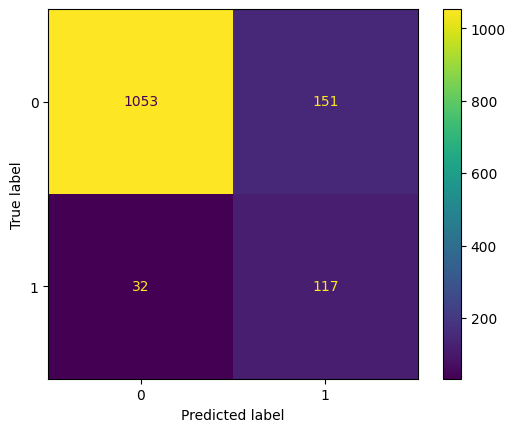

In [ ]:
labels = [0,1]

cm = confusion_matrix(y_test,res_lr,labels=labels)

print(cm)

disp = ConfusionMatrixDisplay(cm,display_labels=labels)
disp.plot();

# Findings

The Logistic Regression model achieves an overall **accuracy** of 86%.

For the majority class (no), **precision** and **F1-score** are very high (0.97 and 0.92), **indicating excellent performance in identifying non-subscribers.**

For the minority class (yes), the model shows high **recall** (0.79), capturing most positive cases, but relatively low precision (0.44), indicating many false positives.

This behavior reflects a common trade-off in imbalanced datasets:

**the model prioritise detecting potential subscribers, even at the cost of misclassifying some non-subscribers.**

The **confusion matrix** shows that the model correctly predicts the majority of negative cases (“no”), with 1,051 true negatives out of 1,204 examples in this class, while 153 examples are incorrectly classified as positive (“yes”).

For the positive class (“yes”), the model correctly identifies 118 cases out of 149, with 30 false negatives.

This pattern is reflected in the classification report: the precision for the negative class is very high (0.97), indicating that when the model predicts “no” it is almost always correct, whereas the precision for the positive class is lower (0.44), showing that many of the “yes” predictions are actually false positives.

# Model Improvement - best threshold for probability of outocme 1 calculation

In [ ]:
res_lr_prob = model_lr.predict_proba(X_test_final)[:,1]

X_prob =pd.DataFrame(X_test_final)
X_prob['result'] = res_lr_prob

X_prob

,age,duration,previous,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_unemployed,job_unknown,marital_married,marital_single,k_basic.6y,k_unknown,housing_yes,contact_telephone,month_dec,month_mar,month_may,month_sep,day_of_week_tue,pdays_2_2 Weeks,pdays_2_3 Weeks,poutcome_nonexistent,poutcome_success,result
0,1.151709,0.922227,1.422535,-2.231365,-1.591543,2.233449,-2.020433,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,0.932727,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,-2.397788,5.171796,0.997500
1,0.086149,-0.103366,1.422535,-0.757990,1.054435,0.632208,-2.751785,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,4.850442,0.932727,-0.760151,-0.076542,-0.099632,-0.710778,7.748835,-0.511692,-0.068956,-0.054044,-2.397788,-0.193356,0.427321
2,0.667363,-0.237807,-0.352887,-2.231365,-1.591543,2.233449,-2.020433,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,-1.232020,1.589439,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,1.954302,-0.068956,-0.054044,0.417051,-0.193356,0.935454
3,0.183018,0.073328,-0.352887,-1.206409,-0.864326,-1.445077,-0.913229,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,0.932727,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0.522413
4,1.442316,0.346051,-0.352887,0.843504,1.508519,-0.298243,0.837130,1.954302,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,-1.072125,1.315529,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0.182277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,1.442316,0.200086,1.422535,-1.206409,-0.864326,-1.445077,-0.913229,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,-2.397788,-0.193356,0.551304
1349,-0.979411,-0.595037,-0.352887,0.843504,1.508519,-0.298243,0.837130,1.954302,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,-1.232020,1.589439,4.283115,-0.206167,0.932727,1.315529,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0.006955
1350,-0.979411,-0.164825,-0.352887,-1.142349,0.808615,0.134525,-2.371862,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,4.943196,-0.158114,-0.091888,0.811675,-0.629153,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0.173983
1351,-0.979411,-0.668019,-0.352887,0.843504,-0.234412,0.935145,0.837130,-0.511692,-0.196375,-0.176511,-0.295059,-0.199356,-0.202298,-0.158114,-0.091888,-1.232020,1.589439,-0.233475,-0.206167,-1.072125,-0.760151,-0.076542,-0.099632,-0.710778,-0.129052,-0.511692,-0.068956,-0.054044,0.417051,-0.193356,0.027442


By default, the logistic model predicts 1 when the probability exceeds 0.5 and 0 otherwise.

The ROC curve helps visualise the best trade-off between the false positive rate and true positive rate across different thresholds.

The AUC (area under the curve) represents the probability that the model ranks a randomly chosen positive observation higher than a randomly chosen negative one, providing a measure of overall discriminative ability.

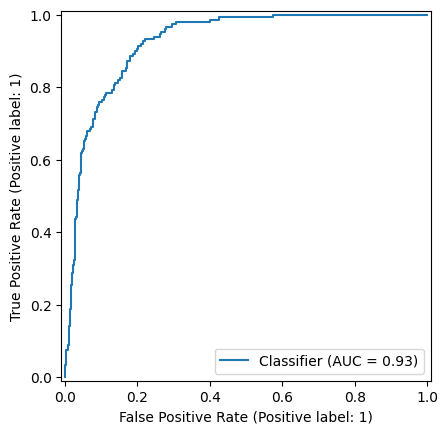

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test,res_lr_prob)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test,res_lr_prob)
# find threshold that maximise difference true positive and false positive
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.23043059004280614


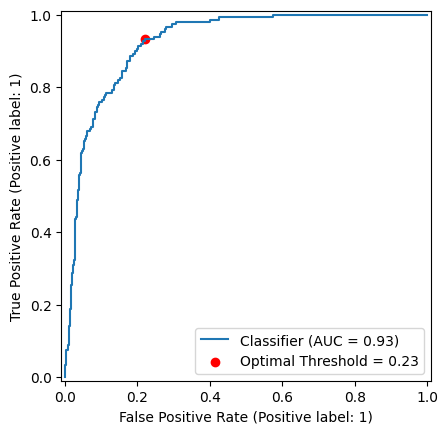

In [ ]:
disp = RocCurveDisplay.from_predictions(y_test,res_lr_prob)
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='r', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.legend()
plt.show()

The Marker indicates the point of best tradeoff for our model for the identification of positive cases.

In [ ]:
new_pred = (X_prob['result'] >= optimal_threshold).astype(int)

In [ ]:
# we recalculate hence the new result applying the new threshold
print(confusion_matrix(y_test, new_pred))
print(classification_report(y_test, new_pred))

[[938 266]
 [ 10 139]]
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      1204
           1       0.34      0.93      0.50       149

    accuracy                           0.80      1353
   macro avg       0.67      0.86      0.69      1353
weighted avg       0.92      0.80      0.83      1353



# Conclusion

Adjusting the classification threshold significantly affects model performance. Initially, the model achieved an overall accuracy of 0.86, which dropped to 0.80 after recalibration, reflecting a trade-off.

For the majority class (class 0), recall decreased from 0.87 to 0.78 and F1-score from 0.92 to 0.87, meaning more negatives are misclassified as positive. Precision slightly increased to 0.99, making negative predictions more conservative.

For the minority class (class 1), recall improved from 0.79 to 0.93, capturing more positive cases, but precision fell from 0.44 to 0.34, increasing false positives. The F1-score slightly decreased from 0.56 to 0.50.

Overall, the threshold adjustment favors a recall-oriented strategy, better for detecting positive cases at the cost of precision and overall accuracy. The original model, by contrast, offers more balanced performance with higher accuracy and better precision for the minority class.

# Decision Tree

A decision tree is a supervised machine learning model that makes predictions by splitting data into branches based on feature values, forming a tree-like structure of decisions.


In our case we will follow the same steps as before but without scaling our features.

In [ ]:
X1 = df1.drop(columns='Target')
y1 = df1['Target']

In [ ]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
X1, y1, test_size=0.33, random_state=42)

In [ ]:
categorical_1=X_train1.select_dtypes(include='object').columns
numerical_1= X_train1.select_dtypes(include = ['int','float']).columns

In [ ]:
X_train_num1 = X_train1[numerical_1].values
X_test_num1 = X_test1[numerical_1].values

In [ ]:
X_train_cat1 = encoder.fit_transform(X_train1[categorical_1])
X_test_cat1 = encoder.transform(X_test1[categorical_1])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
X_train1 = np.hstack((X_train_num1, X_train_cat1))
X_test1 = np.hstack((X_test_num1, X_test_cat1))

In [ ]:
X_train_res2, y_train_res2 = smote.fit_resample(X_train1,y_train1)

One of the key hyperparameters is max_depth, which limits the maximum number of splits from the root to the leaf nodes, controlling the complexity and depth of the decision tree.

In [ ]:
# To choose the depth of the model we will use gridsearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth':[1,2,3,4,5,6,7,8,9,10]}

# Model Initialisation

In [ ]:
tree = DecisionTreeClassifier()

In [ ]:
grid = GridSearchCV(estimator = tree,param_grid=param_grid) # we are going to find what is the best parameter max_depth for our model

In [ ]:
grid.fit(X_train_res2, y_train_res2)
print(grid.best_params_)

{'max_depth': 10}


# Max Depth plot v Accuracy

Visualisation of best trade off between accuracy score and complexity of our model based on max depth used

In [ ]:
from sklearn.metrics import accuracy_score

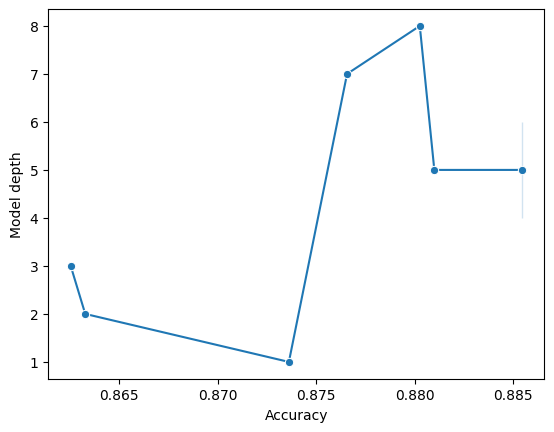

In [ ]:
depth =range(1,9)
acc = []
for i in depth:
  t = DecisionTreeClassifier(max_depth = i)
  t.fit(X_train_res2, y_train_res2)
  r = t.predict(X_test1)
  acc.append(accuracy_score(y_test1,r))


sns.lineplot(x = acc, y = depth,marker = 'o')
plt.xlabel('Accuracy')
plt.ylabel('Model depth')
plt.show();

# Findings

The optimal trade-off occurs at max_depth = 3, as increasing depth beyond this adds five more layers but improves accuracy by only about 1%, offering minimal benefit relative to added complexity.

In [ ]:
tree1 = DecisionTreeClassifier(max_depth = 3)
tree1.fit(X_train_res2, y_train_res2)

DecisionTreeClassifier(max_depth=3)

In [ ]:
res_tree=tree1.predict(X_test1)

              precision    recall  f1-score   support

           0       0.98      0.86      0.92      1208
           1       0.43      0.87      0.58       145

    accuracy                           0.86      1353
   macro avg       0.71      0.87      0.75      1353
weighted avg       0.92      0.86      0.88      1353

[[1041  167]
 [  19  126]]


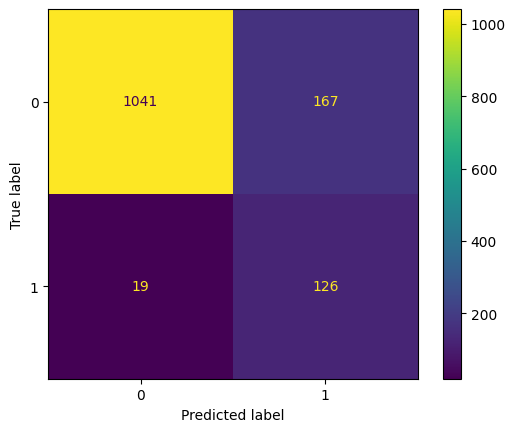

In [ ]:
print(classification_report(y_test1, res_tree))

labels = [0,1]
cm = confusion_matrix(y_test1, res_tree,labels =labels)
CFD = ConfusionMatrixDisplay(cm,display_labels = labels)
print(cm)
CFD.plot()
plt.show();

# decision tree visualisation

In [ ]:
# Reconstruct the column names after hstacking numerical and one-hot encoded categorical features
all_columns_dt = list(numerical_1) + list(encoder.get_feature_names_out(categorical_1))

# Create the DataFrame with the correct column names
columns_graph = pd.DataFrame(X_train_res2, columns=all_columns_dt)

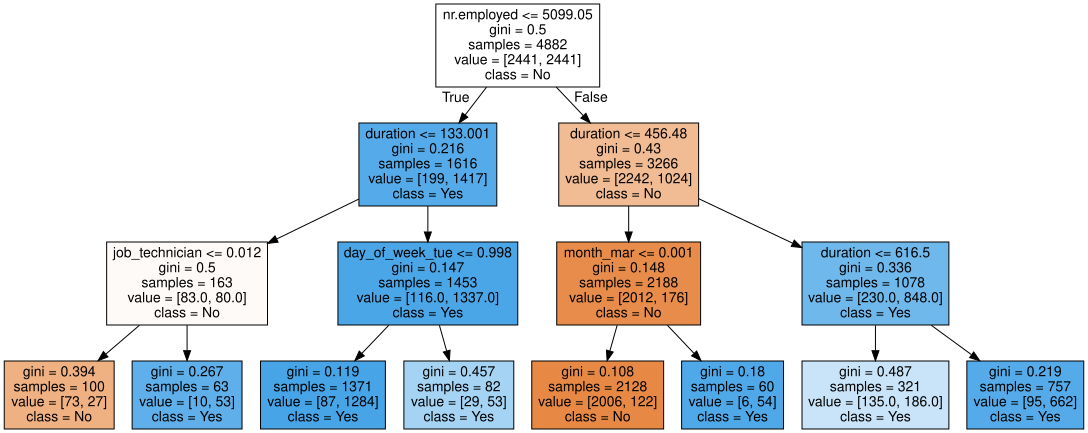

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

DT = export_graphviz(tree1,
                           out_file=None,
                           feature_names=columns_graph.columns,
                           class_names=['No','Yes'],
                           filled=True)

graph = graphviz.Source(DT)
graph

In [ ]:
from sklearn.tree import export_text
tree_rules = export_text(tree1, feature_names=list(columns_graph.columns))
print(tree_rules)

|--- nr.employed <= 5099.05
|   |--- duration <= 133.00
|   |   |--- job_technician <= 0.01
|   |   |   |--- class: 0
|   |   |--- job_technician >  0.01
|   |   |   |--- class: 1
|   |--- duration >  133.00
|   |   |--- day_of_week_tue <= 1.00
|   |   |   |--- class: 1
|   |   |--- day_of_week_tue >  1.00
|   |   |   |--- class: 1
|--- nr.employed >  5099.05
|   |--- duration <= 456.48
|   |   |--- month_mar <= 0.00
|   |   |   |--- class: 0
|   |   |--- month_mar >  0.00
|   |   |   |--- class: 1
|   |--- duration >  456.48
|   |   |--- duration <= 616.50
|   |   |   |--- class: 1
|   |   |--- duration >  616.50
|   |   |   |--- class: 1



#Findings

Nr.employed works as the root node, showing that overall employment levels are the most influential variable.

For lower employment (≤ 5099.05), call duration becomes key, with shorter calls usually leading to negative outcomes unless the contact is a technician or occurs on a Tuesday, which increases positive responses.

For higher employment (> 5099.05), longer calls and contacts in March strongly increase the likelihood of a positive outcome, with most long calls resulting in class 1 predictions.

Overall, the tree shows that economic conditions, call duration, month, job type, and day of the week are the main drivers.

# Decision Tree Performances

The decision tree achieves an overall accuracy of 0.86, but this should be interpreted cautiously due to the class imbalance. For the positive class (1), recall is high at 0.87, capturing most actual positives, though precision is low (0.43), resulting in many false positives (167).

For the negative class (0), performance is strong, with precision of 0.98 and recall of 0.86, showing reliable classification of the majority class. The difference between the macro F1 (0.75) and weighted F1 (0.88) highlights the impact of imbalance.

Overall, the model favors recall for the positive class at the expense of precision, making it suitable when detecting positives is more important than avoiding false alarms.

# Models comparison

In [ ]:
metrics = [] #create empty list

# Logistic Reg
metrics.append({
    'Model': 'Logistic regression',
    'Precision 0' : precision_score(y_test,new_pred,pos_label=0),# pos label allow us to focus on label 1 or 0
    'Recall 0': recall_score(y_test,new_pred,pos_label=0),
    'f1 0':f1_score(y_test,new_pred,pos_label=0),
    # we repeat the same for label 1
    'Precision 1' : precision_score(y_test,new_pred,pos_label=1),# pos label allow us to focus on label 1 or 0
    'Recall 1': recall_score(y_test,new_pred,pos_label=1),
    'f1 1':f1_score(y_test,new_pred,pos_label=1)
})

# Decision Tree

metrics.append({
    'Model': 'Decision Tree',
    'Precision 0' : precision_score(y_test1,res_tree,pos_label=0),# pos label allow us to focus on label 1 or 0
    'Recall 0': recall_score(y_test1,res_tree,pos_label=0),
    'f1 0':f1_score(y_test1,res_tree,pos_label=0),
    # we repeat the same for label 1
    'Precision 1' : precision_score(y_test1,res_tree,pos_label=1),# pos label allow us to focus on label 1 or 0
    'Recall 1': recall_score(y_test1,res_tree,pos_label=1),
    'f1 1':f1_score(y_test1,res_tree,pos_label=1)
    })


# We transform the list in a DataFrame
df_model_evaluation = pd.DataFrame(metrics)

df_model_evaluation

,Model,Precision 0,Recall 0,f1 0,Precision 1,Recall 1,f1 1
0,Logistic regression,0.989451,0.779070,0.871747,0.343210,0.932886,0.501805
1,Decision Tree,0.982075,0.861755,0.917989,0.430034,0.868966,0.575342


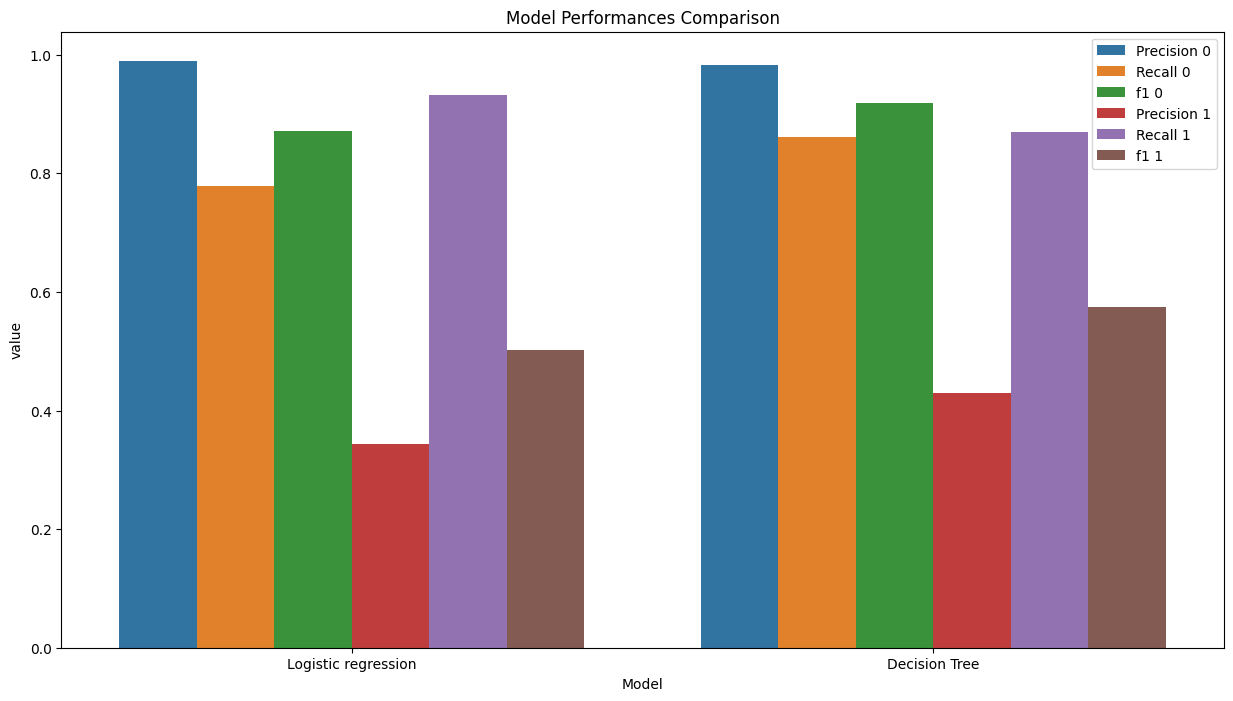

In [ ]:
df_evaluation = pd.melt(df_model_evaluation, id_vars='Model',value_vars=['Precision 0','Recall 0','f1 0','Precision 1','Recall 1','f1 1'],var_name='Metric')

plt.figure(figsize=(15,8))
sns.barplot(data = df_evaluation, x = 'Model',y = 'value',hue = 'Metric')
plt.title('Model Performances Comparison')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

# Conclusion

The comparison between logistic regression and the decision tree highlights key trade-offs.

For the minority class (responders), logistic regression has higher recall (0.93 vs 0.87), capturing more potential customers, but lower precision (0.34 vs 0.43), generating more false positives.

The decision tree predicts responders more conservatively, achieving a slightly higher F1-score (0.58 vs 0.50), reflecting a better balance between precision and recall.

From a marketing perspective, logistic regression is preferable as it captures many responders as possible.

The decision tree is better in reducing wasted contacts and improving efficiency.

Overall, the decision tree offers a more balanced strategy, while logistic regression focuses on detecting the largest number of potential responders.